In [ ]:
!pip install shapely diskpack circlify

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon, Circle as MplCircle
from dataclasses import dataclass
from typing import List, Tuple, Callable
from shapely.geometry import Polygon, Point

from diskpack import CirclePacker, PackingConfig

FINDING OPTIMAL THRESHOLD
Threshold:   100 | Time: 19.03s | Circles: 251
Threshold:   300 | Time: 4.88s | Circles: 251
Threshold:   500 | Time: 3.96s | Circles: 251
Threshold:   750 | Time: 4.27s | Circles: 251
Threshold:  1000 | Time: 4.66s | Circles: 251
Threshold:  2000 | Time: 3.96s | Circles: 251
Threshold: 10000 | Time: 4.43s | Circles: 251


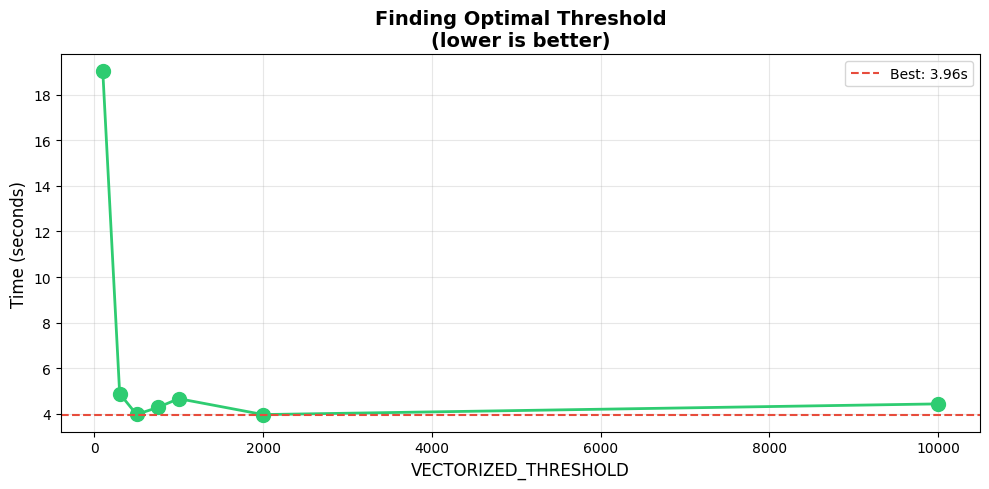


→ Optimal threshold: 2000 (3.96s)
→ Recommendation: Set VECTORIZED_THRESHOLD = 2000


In [ ]:
print("=" * 75)
print("FINDING OPTIMAL THRESHOLD")
print("=" * 75)

import diskpack.packer as packer_module

# Test different thresholds
thresholds = [100, 300, 500, 750, 1000, 2000, 10000]
vertices = [(0, 0), (200, 0), (200, 200), (0, 200)]

timing_results = []

for threshold in thresholds:
    packer_module.VECTORIZED_THRESHOLD = threshold

    np.random.seed(42)
    config = PackingConfig(
        padding=0.5,
        min_radius=1.0,
        max_failed_attempts=300,
        sample_batch_size=100,
    )
    packer = CirclePacker([np.array(vertices)], config)

    start = time.perf_counter()
    circles = packer.pack()
    elapsed = time.perf_counter() - start

    timing_results.append((threshold, elapsed, len(circles)))
    print(f"Threshold: {threshold:5} | Time: {elapsed:.2f}s | Circles: {len(circles)}")

# Reset to default
packer_module.VECTORIZED_THRESHOLD = 300

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
thresholds_plot = [t for t, _, _ in timing_results]
times_plot = [t for _, t, _ in timing_results]

ax.plot(thresholds_plot, times_plot, 'o-', markersize=10, linewidth=2, color='#2ecc71')
ax.axhline(y=min(times_plot), color='#e74c3c', linestyle='--', label=f'Best: {min(times_plot):.2f}s')

ax.set_xlabel('VECTORIZED_THRESHOLD', fontsize=12)
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_title('Finding Optimal Threshold\n(lower is better)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_threshold, best_time, _ = min(timing_results, key=lambda x: x[1])
print(f"\n→ Optimal threshold: {best_threshold} ({best_time:.2f}s)")
print(f"→ Recommendation: Set VECTORIZED_THRESHOLD = {best_threshold}")

In [ ]:
@dataclass
class BenchmarkResult:
    name: str
    time_seconds: float
    circles: List[Tuple[float, float, float]]
    polygon_area: float

    @property
    def circle_count(self) -> int:
        return len(self.circles)

    @property
    def total_circle_area(self) -> float:
        return sum(np.pi * r**2 for _, _, r in self.circles)

    @property
    def density(self) -> float:
        return (self.total_circle_area / self.polygon_area) * 100

    def summary(self) -> str:
        return f"{self.name:25} | Time: {self.time_seconds:6.3f}s | Circles: {self.circle_count:4} | Density: {self.density:5.1f}%"

In [ ]:
def pack_diskpack(
    vertices: List[Tuple[float, float]],
    max_failed_attempts: int = 500,
    min_radius: float = 1.0,
    padding: float = 0.5,
    fixed_radius: float = None,
) -> Tuple[List[Tuple[float, float, float]], float]:
    config = PackingConfig(
        padding=padding,
        min_radius=min_radius,
        max_failed_attempts=max_failed_attempts,
        sample_batch_size=100,
        fixed_radius=fixed_radius,
    )
    packer = CirclePacker([np.array(vertices)], config)
    start = time.perf_counter()
    circles = packer.pack()
    elapsed = time.perf_counter() - start
    return circles, elapsed


def pack_shapely_naive(
    vertices: List[Tuple[float, float]],
    max_failed_attempts: int = 500,
    min_radius: float = 1.0,
    padding: float = 0.5,
    fixed_radius: float = None,
) -> Tuple[List[Tuple[float, float, float]], float]:
    polygon = Polygon(vertices)
    bounds = polygon.bounds
    circles = []
    start = time.perf_counter()
    consecutive_fails = 0

    while consecutive_fails < max_failed_attempts:
        x = np.random.uniform(bounds[0], bounds[2])
        y = np.random.uniform(bounds[1], bounds[3])
        pt = Point(x, y)

        if not polygon.contains(pt):
            consecutive_fails += 1
            continue

        max_r = polygon.exterior.distance(pt)
        for cx, cy, cr in circles:
            dist_to_circle = np.sqrt((x - cx)**2 + (y - cy)**2) - cr
            max_r = min(max_r, dist_to_circle)
        max_r -= padding

        if fixed_radius is not None:
            if max_r >= fixed_radius:
                max_r = fixed_radius
            else:
                consecutive_fails += 1
                continue

        if max_r >= min_radius:
            circles.append((x, y, max_r))
            consecutive_fails = 0
        else:
            consecutive_fails += 1

    elapsed = time.perf_counter() - start
    return circles, elapsed


def pack_shapely_batched(
    vertices: List[Tuple[float, float]],
    max_failed_attempts: int = 500,
    min_radius: float = 1.0,
    padding: float = 0.5,
    fixed_radius: float = None,
    batch_size: int = 100,
) -> Tuple[List[Tuple[float, float, float]], float]:
    polygon = Polygon(vertices)
    bounds = polygon.bounds
    circles = []
    start = time.perf_counter()
    consecutive_fails = 0

    while consecutive_fails < max_failed_attempts:
        xs = np.random.uniform(bounds[0], bounds[2], batch_size)
        ys = np.random.uniform(bounds[1], bounds[3], batch_size)
        best_pt, best_r = None, 0

        for x, y in zip(xs, ys):
            pt = Point(x, y)
            if not polygon.contains(pt):
                continue

            max_r = polygon.exterior.distance(pt)
            for cx, cy, cr in circles:
                dist_to_circle = np.sqrt((x - cx)**2 + (y - cy)**2) - cr
                max_r = min(max_r, dist_to_circle)
            max_r -= padding

            if fixed_radius is not None:
                if max_r >= fixed_radius:
                    max_r = fixed_radius
                else:
                    continue

            if max_r > best_r:
                best_pt, best_r = (x, y), max_r

        if best_pt is not None and best_r >= min_radius:
            circles.append((best_pt[0], best_pt[1], best_r))
            consecutive_fails = 0
        else:
            consecutive_fails += 1

    elapsed = time.perf_counter() - start
    return circles, elapsed

In [ ]:
def visualize_comparison(shape_name, vertices, results):
    n_results = len(results)
    fig, axes = plt.subplots(1, n_results, figsize=(6 * n_results, 6))
    if n_results == 1:
        axes = [axes]

    colors = {
        "diskpack": "#2ecc71",
        "shapely (naive)": "#e74c3c",
        "shapely (batched)": "#3498db",
    }

    for ax, result in zip(axes, results):
        poly_patch = MplPolygon(vertices, fill=False, edgecolor="black", linewidth=2)
        ax.add_patch(poly_patch)

        color = colors.get(result.name, "#95a5a6")
        for x, y, r in result.circles:
            circle = MplCircle((x, y), r, fill=True, facecolor=color,
                              edgecolor="black", alpha=0.7, linewidth=0.5)
            ax.add_patch(circle)

        ax.set_title(f"{result.name}\n{result.circle_count} circles | {result.density:.1f}%\n{result.time_seconds:.3f}s",
                    fontsize=12, fontweight="bold")
        ax.set_aspect("equal")
        ax.autoscale_view()
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f"{shape_name}", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


def visualize_single(shape_name, vertices, result):
    fig, ax = plt.subplots(figsize=(8, 8))

    poly_patch = MplPolygon(vertices, fill=False, edgecolor="black", linewidth=2)
    ax.add_patch(poly_patch)

    if result.circles:
        radii = [c[2] for c in result.circles]
        max_r, min_r = max(radii), min(radii)
        for x, y, r in result.circles:
            norm_r = (r - min_r) / (max_r - min_r + 1e-10)
            circle = MplCircle((x, y), r, fill=True, facecolor=plt.cm.viridis(norm_r),
                              edgecolor="black", alpha=0.8, linewidth=0.3)
            ax.add_patch(circle)

    ax.set_title(f"{shape_name} — {result.name}\n{result.circle_count} circles | {result.density:.1f}% | {result.time_seconds:.3f}s",
                fontsize=14, fontweight="bold")
    ax.set_aspect("equal")
    ax.autoscale_view()
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

In [ ]:
def run_benchmark(name, vertices, pack_fn, **kwargs):
    polygon = Polygon(vertices)
    circles, elapsed = pack_fn(vertices, **kwargs)
    return BenchmarkResult(name=name, time_seconds=elapsed, circles=circles, polygon_area=polygon.area)


def run_all_benchmarks(vertices, max_failed_attempts=500, min_radius=1.0, padding=0.5, fixed_radius=None, seed=42):
    common_params = {
        "max_failed_attempts": max_failed_attempts,
        "min_radius": min_radius,
        "padding": padding,
        "fixed_radius": fixed_radius,
    }
    results = []

    np.random.seed(seed)
    results.append(run_benchmark("diskpack", vertices, pack_diskpack, **common_params))

    np.random.seed(seed)
    results.append(run_benchmark("shapely (naive)", vertices, pack_shapely_naive, **common_params))

    np.random.seed(seed)
    results.append(run_benchmark("shapely (batched)", vertices, pack_shapely_batched, **common_params))

    return results

In [ ]:
shapes = {
    "Square": [(0, 0), (100, 0), (100, 100), (0, 100)],
    "L-Shape": [(0, 0), (60, 0), (60, 40), (40, 40), (40, 100), (0, 100)],
    "Star": [
        (50, 0), (61, 35), (98, 35), (68, 57), (79, 91),
        (50, 70), (21, 91), (32, 57), (2, 35), (39, 35)
    ],
}

VARIABLE RADIUS BENCHMARK

SQUARE (area: 10000)
---------------------------------------------------------------------------
diskpack                  | Time:  0.679s | Circles:   47 | Density:  86.7%
shapely (naive)           | Time:  1.424s | Circles:  109 | Density:  73.4%
shapely (batched)         | Time: 19.569s | Circles:   60 | Density:  85.3%


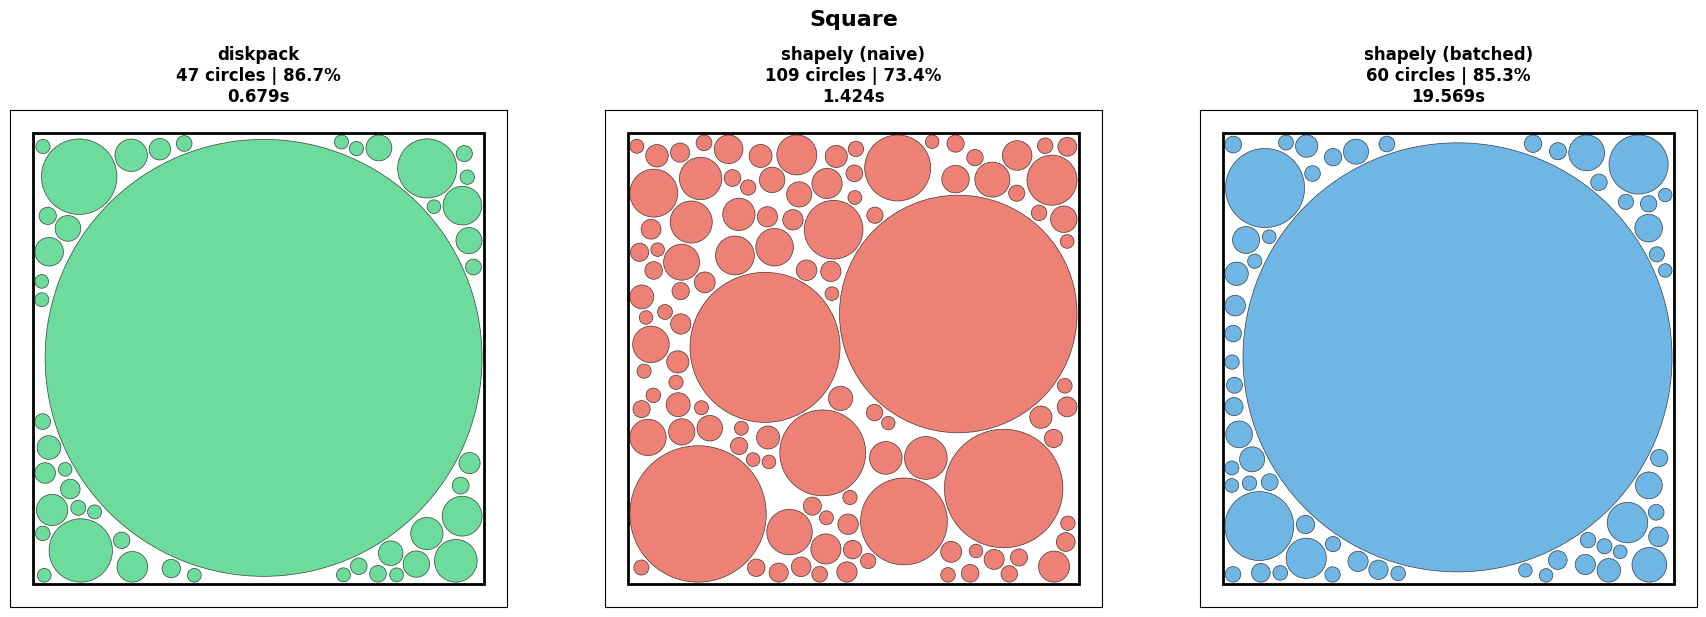


L-SHAPE (area: 4800)
---------------------------------------------------------------------------
diskpack                  | Time:  0.435s | Circles:   49 | Density:  76.4%
shapely (naive)           | Time:  0.250s | Circles:   62 | Density:  65.0%
shapely (batched)         | Time:  7.854s | Circles:   41 | Density:  76.3%


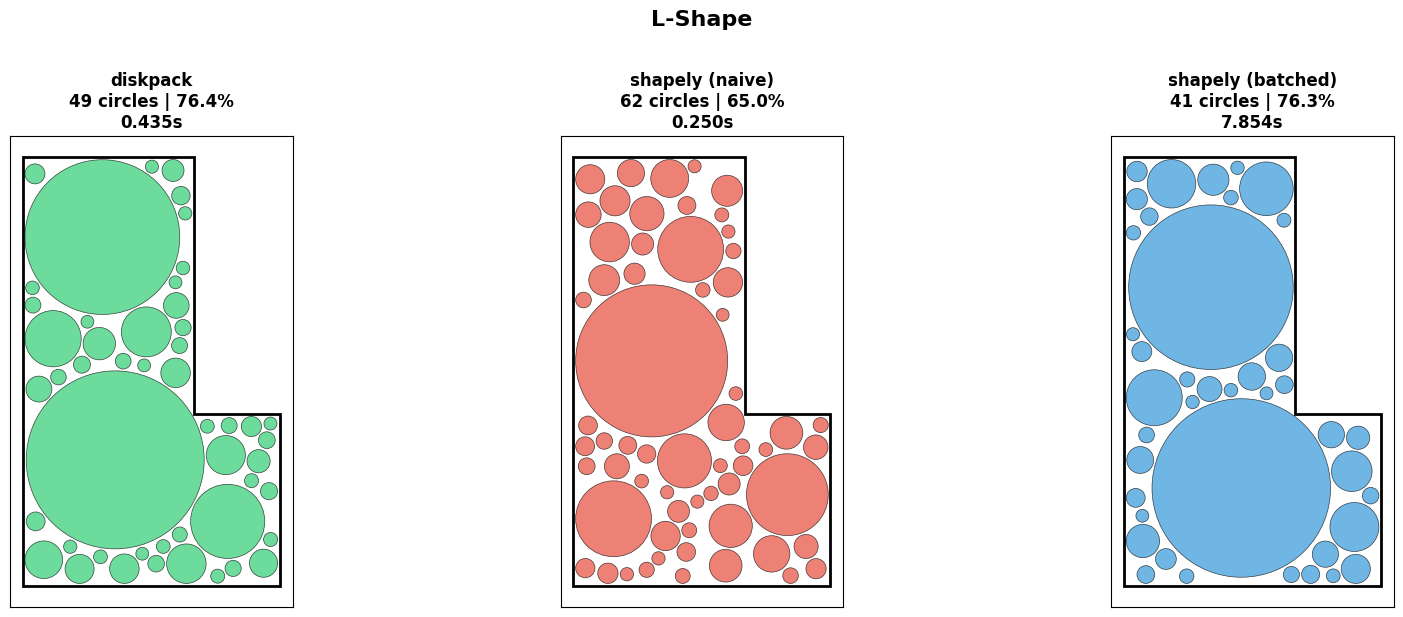


STAR (area: 2826)
---------------------------------------------------------------------------
diskpack                  | Time:  0.281s | Circles:   39 | Density:  66.4%
shapely (naive)           | Time:  0.103s | Circles:   38 | Density:  57.1%
shapely (batched)         | Time:  3.482s | Circles:   38 | Density:  64.4%


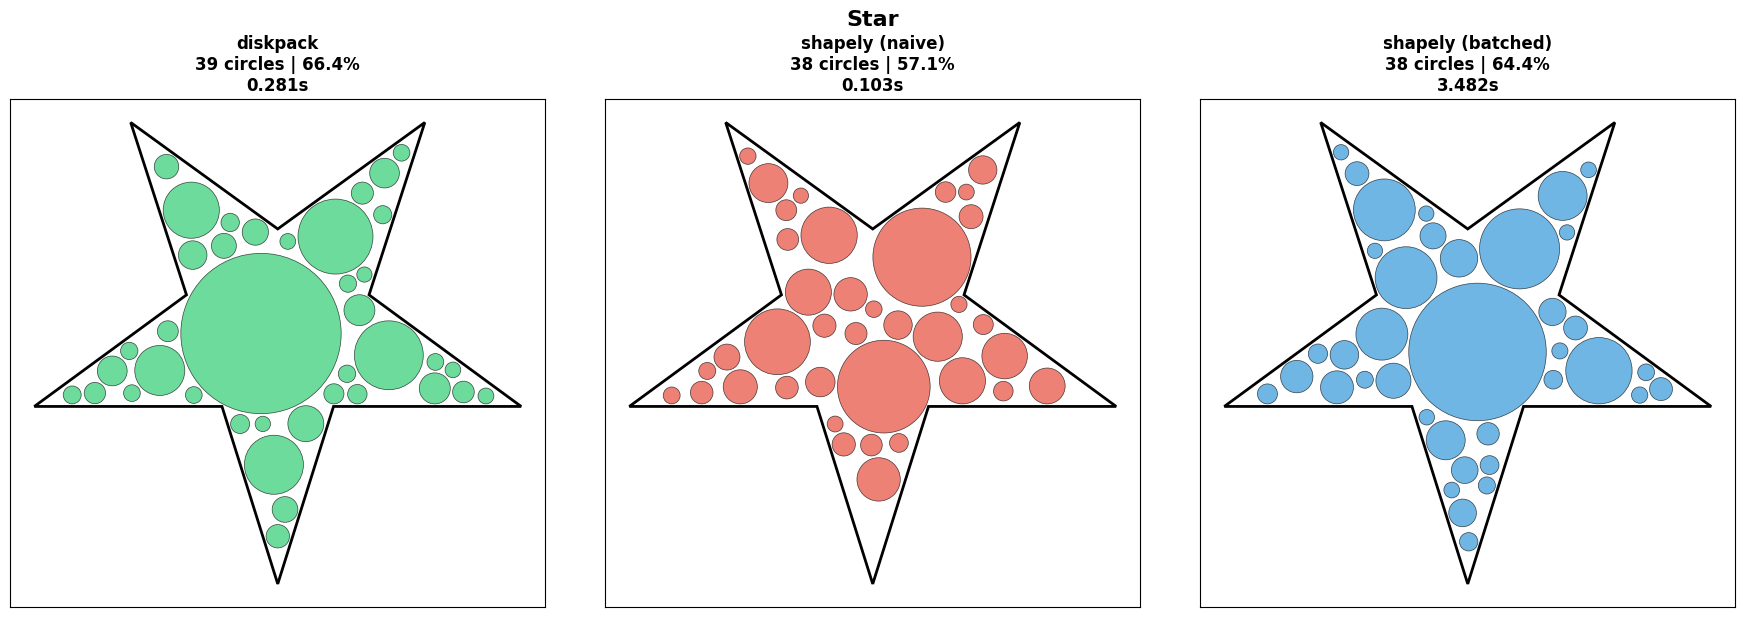

In [ ]:
print("=" * 75)
print("VARIABLE RADIUS BENCHMARK")
print("=" * 75)

for shape_name, vertices in shapes.items():
    print(f"\n{shape_name.upper()} (area: {Polygon(vertices).area:.0f})")
    print("-" * 75)

    results = run_all_benchmarks(
        vertices,
        max_failed_attempts=300,
        min_radius=1.5,
        padding=0.5,
    )

    for r in results:
        print(r.summary())

    visualize_comparison(shape_name, vertices, results)

FIXED RADIUS BENCHMARK (r=3.0)

SQUARE (area: 10000)
---------------------------------------------------------------------------
diskpack                  | Time:  0.025s | Circles:  216 | Density:  61.1%
shapely (naive)           | Time:  1.192s | Circles:  137 | Density:  38.7%
shapely (batched)         | Time: 39.283s | Circles:  148 | Density:  41.8%


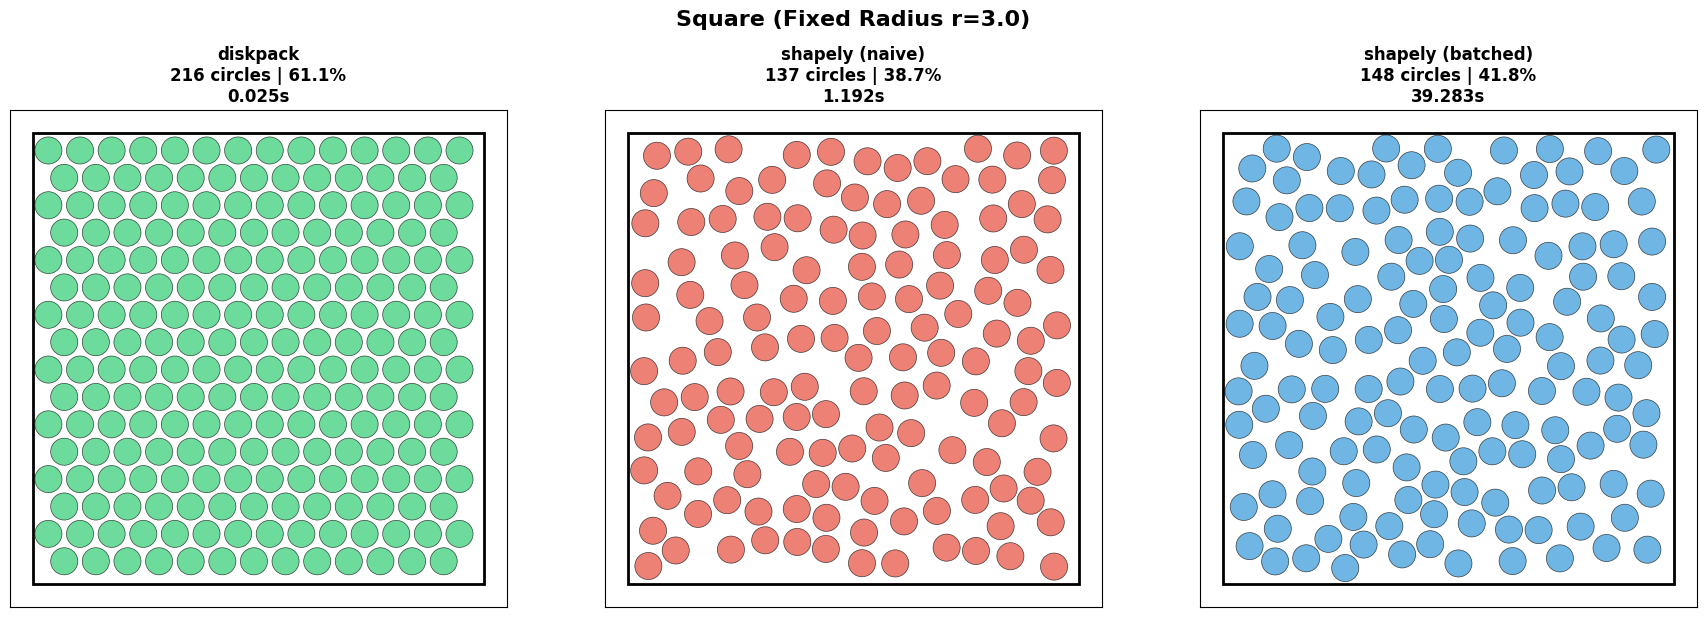

In [ ]:
print("=" * 75)
print("FIXED RADIUS BENCHMARK (r=3.0)")
print("=" * 75)

vertices = shapes["Square"]
print(f"\nSQUARE (area: {Polygon(vertices).area:.0f})")
print("-" * 75)

results = run_all_benchmarks(
    vertices,
    max_failed_attempts=500,
    min_radius=3.0,
    padding=0.5,
    fixed_radius=3.0,
)

for r in results:
    print(r.summary())

visualize_comparison("Square (Fixed Radius r=3.0)", vertices, results)

DISKPACK HEX GRID SHOWCASE
Hex grid: 314 total -> 232 inside -> 216 valid

Square: diskpack (hex grid)       | Time:  0.024s | Circles:  216 | Density:  61.1%


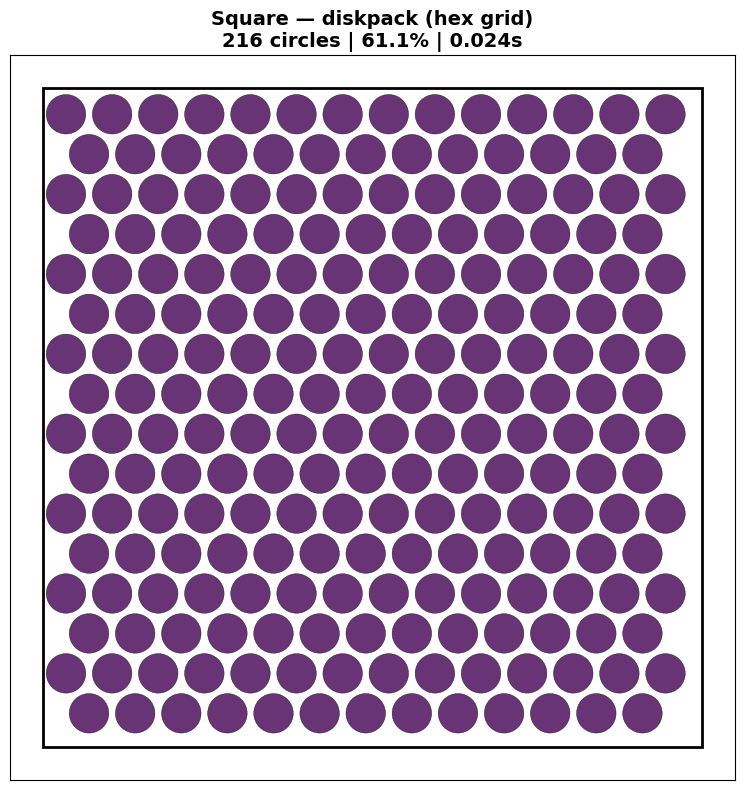

Hex grid: 209 total -> 114 inside -> 98 valid

L-Shape: diskpack (hex grid)       | Time:  0.013s | Circles:   98 | Density:  57.7%


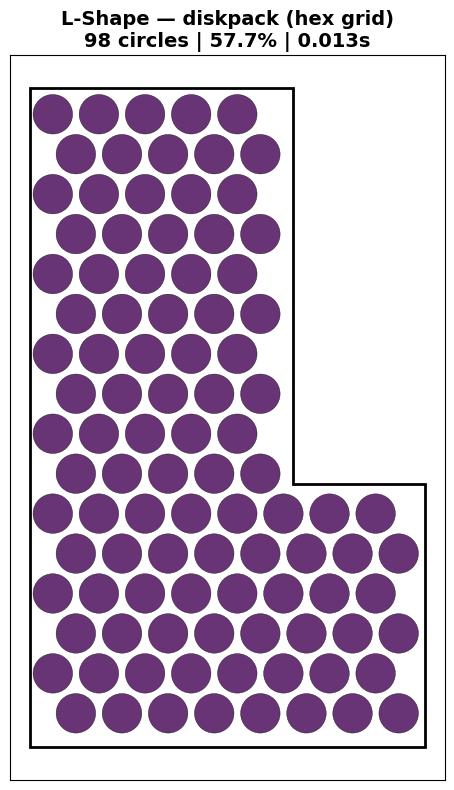

Hex grid: 288 total -> 73 inside -> 40 valid

Star: diskpack (hex grid)       | Time:  0.007s | Circles:   40 | Density:  40.0%


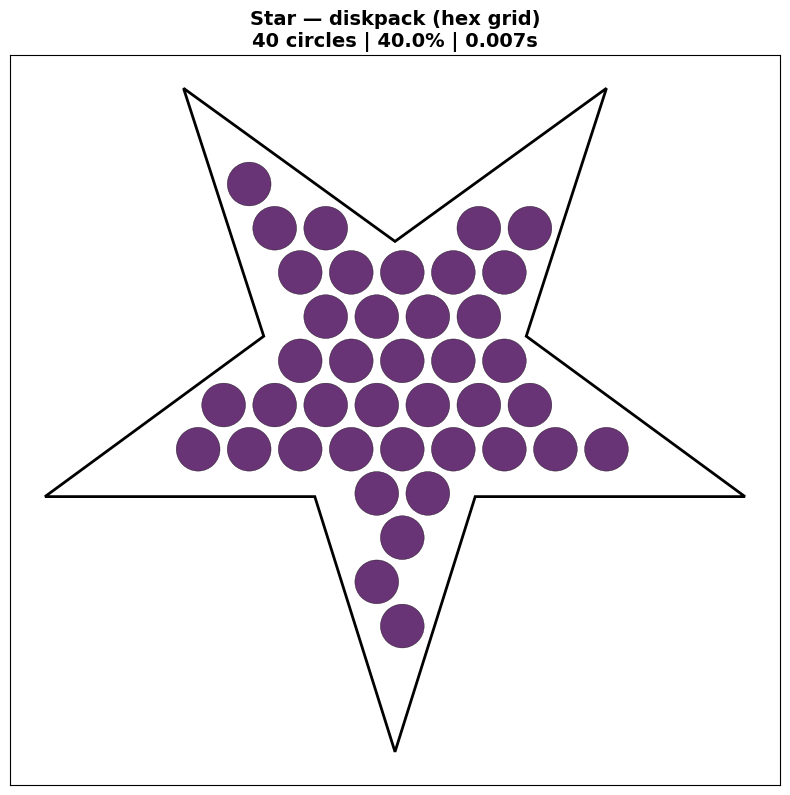

In [ ]:
print("=" * 75)
print("DISKPACK HEX GRID SHOWCASE")
print("=" * 75)

for shape_name, vertices in shapes.items():
    config = PackingConfig(
        padding=0.5,
        fixed_radius=3.0,
        verbose=True,
    )
    packer = CirclePacker([np.array(vertices)], config)

    start = time.perf_counter()
    circles = packer.pack()
    elapsed = time.perf_counter() - start

    result = BenchmarkResult(
        name="diskpack (hex grid)",
        time_seconds=elapsed,
        circles=circles,
        polygon_area=Polygon(vertices).area,
    )

    print(f"\n{shape_name}: {result.summary()}")
    visualize_single(shape_name, vertices, result)

HEX GRID vs ORGANIC PLACEMENT (fixed radius=3.0)
hex grid                  | Time:  0.023s | Circles:  216 | Density:  61.1%
organic                   | Time:  1.612s | Circles:  153 | Density:  43.3%


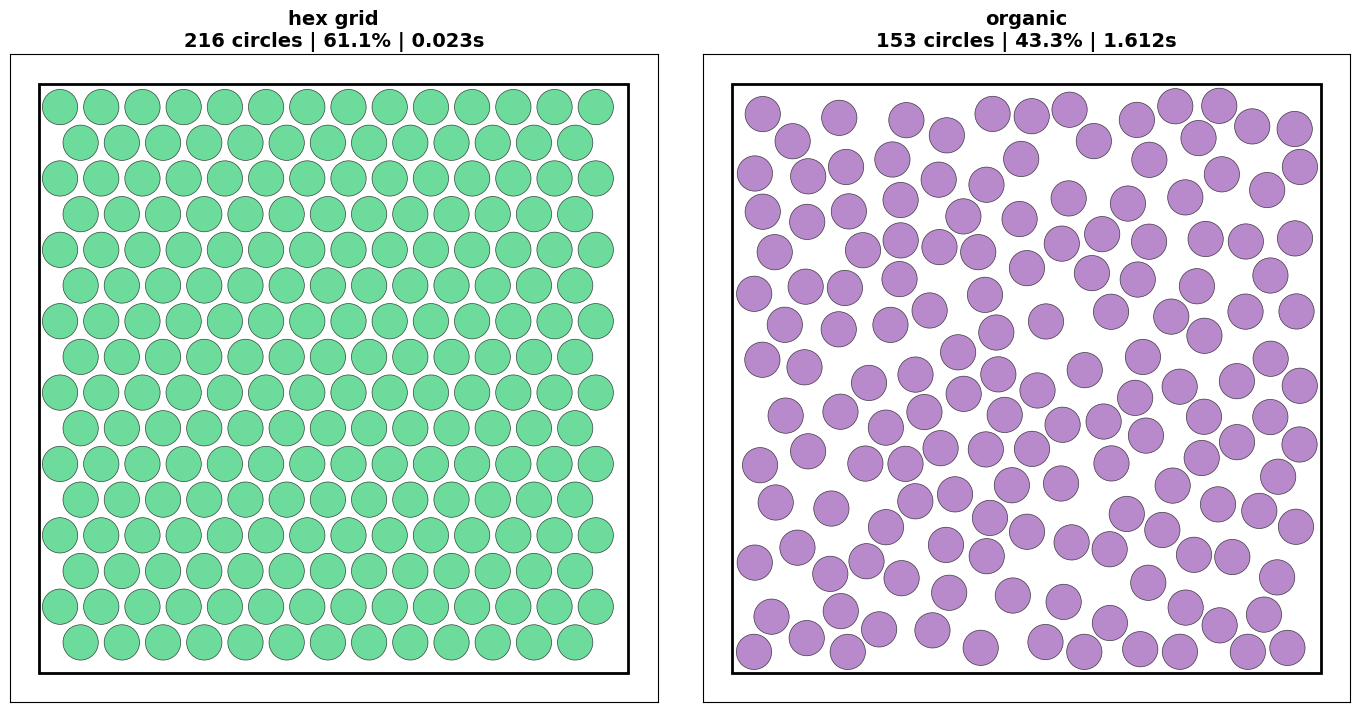

In [ ]:
print("=" * 75)
print("HEX GRID vs ORGANIC PLACEMENT (fixed radius=3.0)")
print("=" * 75)

vertices = shapes["Square"]

# Hex grid (default)
np.random.seed(42)
config_hex = PackingConfig(fixed_radius=3.0, padding=0.5, use_hex_grid=True)
packer_hex = CirclePacker([np.array(vertices)], config_hex)
start = time.perf_counter()
circles_hex = packer_hex.pack()
time_hex = time.perf_counter() - start

result_hex = BenchmarkResult("hex grid", time_hex, circles_hex, Polygon(vertices).area)

# Organic (random sampling)
np.random.seed(42)
config_organic = PackingConfig(fixed_radius=3.0, padding=0.5, use_hex_grid=False, max_failed_attempts=500)
packer_organic = CirclePacker([np.array(vertices)], config_organic)
start = time.perf_counter()
circles_organic = packer_organic.pack()
time_organic = time.perf_counter() - start

result_organic = BenchmarkResult("organic", time_organic, circles_organic, Polygon(vertices).area)

print(result_hex.summary())
print(result_organic.summary())

# Visualize side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, result, color in zip(axes, [result_hex, result_organic], ["#2ecc71", "#9b59b6"]):
    poly_patch = MplPolygon(vertices, fill=False, edgecolor="black", linewidth=2)
    ax.add_patch(poly_patch)

    for x, y, r in result.circles:
        circle = MplCircle((x, y), r, fill=True, facecolor=color,
                          edgecolor="black", alpha=0.7, linewidth=0.5)
        ax.add_patch(circle)

    ax.set_title(f"{result.name}\n{result.circle_count} circles | {result.density:.1f}% | {result.time_seconds:.3f}s",
                fontsize=14, fontweight="bold")
    ax.set_aspect("equal")
    ax.autoscale_view()
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

VECTORIZED vs SPATIAL INDEX THRESHOLD TEST
Always Vectorized         | Time:  4.508s | Circles:  251 | Density:  91.2%
Always Spatial Index      | Time: 12.960s | Circles:  251 | Density:  91.2%
Hybrid (default)          | Time:  4.405s | Circles:  251 | Density:  91.2%


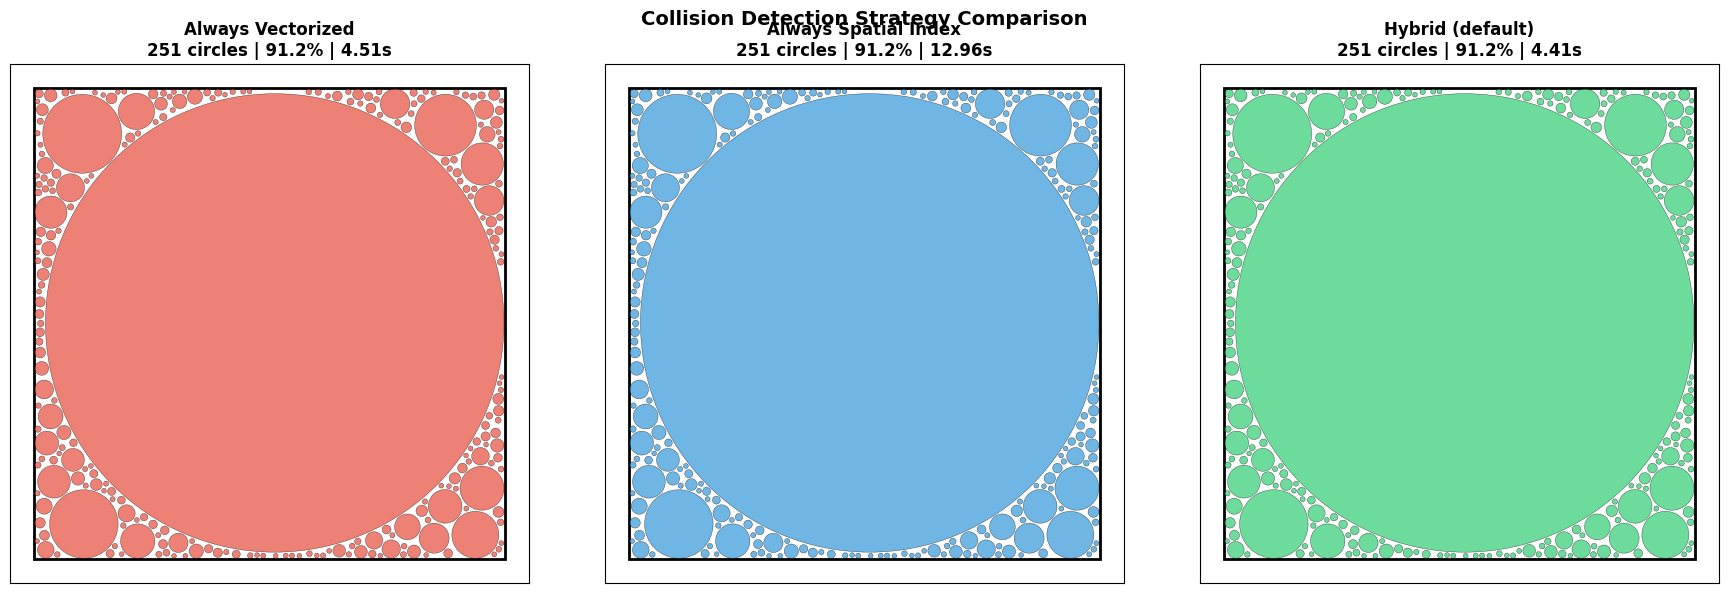


---------------------------------------------------------------------------
ANALYSIS:
---------------------------------------------------------------------------
Fastest: Hybrid (default) (4.41s)
All methods produce identical density (same seed, same algorithm)
Hybrid switches from vectorized to spatial at 300 circles


In [ ]:
print("=" * 75)
print("VECTORIZED vs SPATIAL INDEX THRESHOLD TEST")
print("=" * 75)

import time

# We'll test with a larger shape and more circles to see the difference
vertices = [(0, 0), (200, 0), (200, 200), (0, 200)]  # Larger square

# Temporarily modify the threshold to force each mode
import diskpack.packer as packer_module

results = []

for threshold, label in [(10000, "Always Vectorized"), (0, "Always Spatial Index"), (300, "Hybrid (default)")]:
    # Set threshold
    original_threshold = packer_module.VECTORIZED_THRESHOLD
    packer_module.VECTORIZED_THRESHOLD = threshold

    np.random.seed(42)
    config = PackingConfig(
        padding=0.5,
        min_radius=1.0,
        max_failed_attempts=300,
        sample_batch_size=100,
    )
    packer = CirclePacker([np.array(vertices)], config)

    start = time.perf_counter()
    circles = packer.pack()
    elapsed = time.perf_counter() - start

    # Restore threshold
    packer_module.VECTORIZED_THRESHOLD = original_threshold

    result = BenchmarkResult(label, elapsed, circles, Polygon(vertices).area)
    results.append(result)
    print(result.summary())

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ["#e74c3c", "#3498db", "#2ecc71"]

for ax, result, color in zip(axes, results, colors):
    poly_patch = MplPolygon(vertices, fill=False, edgecolor="black", linewidth=2)
    ax.add_patch(poly_patch)

    for x, y, r in result.circles:
        circle = MplCircle((x, y), r, fill=True, facecolor=color,
                          edgecolor="black", alpha=0.7, linewidth=0.3)
        ax.add_patch(circle)

    ax.set_title(f"{result.name}\n{result.circle_count} circles | {result.density:.1f}% | {result.time_seconds:.2f}s",
                fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.autoscale_view()
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Collision Detection Strategy Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Summary
print("\n" + "-" * 75)
print("ANALYSIS:")
print("-" * 75)
fastest = min(results, key=lambda r: r.time_seconds)
print(f"Fastest: {fastest.name} ({fastest.time_seconds:.2f}s)")
print(f"All methods produce identical density (same seed, same algorithm)")
print(f"Hybrid switches from vectorized to spatial at {300} circles")

FRONT-BASED PACKING TEST
  Seeded 433 initial candidates

---------------------------------------------------------------------------
Random Sampling           | Time:  0.340s | Circles:   49 | Density:  86.4%
Front-Based               | Time:  0.372s | Circles:   70 | Density:  86.0%


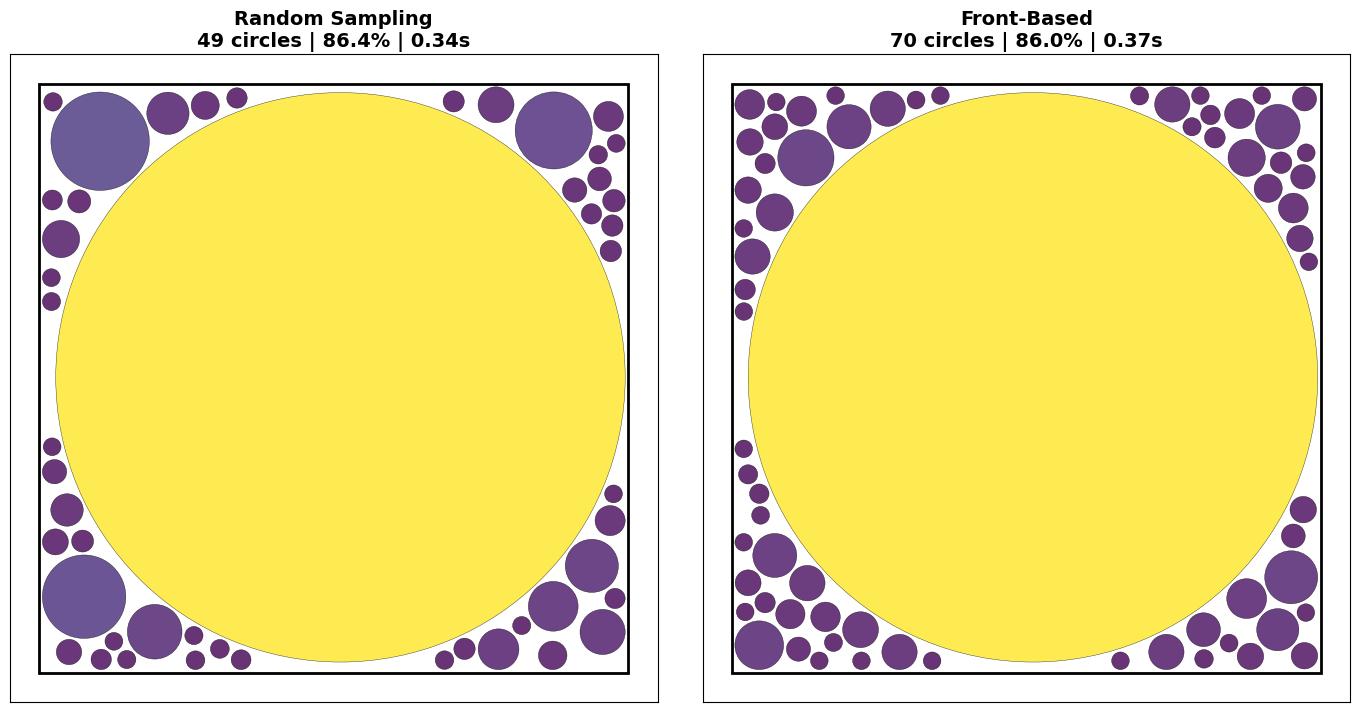

In [ ]:
print("=" * 75)
print("FRONT-BASED PACKING TEST")
print("=" * 75)

vertices = shapes["Square"]

results = []

# Random sampling
np.random.seed(42)
config_random = PackingConfig(
    padding=0.5,
    min_radius=1.5,
    max_failed_attempts=300,
    use_front_packing=False,
)
packer = CirclePacker([np.array(vertices)], config_random)
start = time.perf_counter()
circles = packer.pack()
elapsed = time.perf_counter() - start
results.append(BenchmarkResult("Random Sampling", elapsed, circles, Polygon(vertices).area))

# Front-based
np.random.seed(42)
config_front = PackingConfig(
    padding=0.5,
    min_radius=1.5,
    use_front_packing=True,
    verbose=True,
)
packer = CirclePacker([np.array(vertices)], config_front)
start = time.perf_counter()
circles = packer.pack()
elapsed = time.perf_counter() - start
results.append(BenchmarkResult("Front-Based", elapsed, circles, Polygon(vertices).area))

print("\n" + "-" * 75)
for r in results:
    print(r.summary())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
colors = ["#3498db", "#2ecc71"]

for ax, result, color in zip(axes, results, colors):
    poly_patch = MplPolygon(vertices, fill=False, edgecolor="black", linewidth=2)
    ax.add_patch(poly_patch)

    if result.circles:
        radii = [c[2] for c in result.circles]
        max_r, min_r = max(radii), min(radii)
        for x, y, r in result.circles:
            norm_r = (r - min_r) / (max_r - min_r + 1e-10)
            circle = MplCircle((x, y), r, fill=True, facecolor=plt.cm.viridis(norm_r),
                              edgecolor="black", alpha=0.8, linewidth=0.3)
            ax.add_patch(circle)

    ax.set_title(f"{result.name}\n{result.circle_count} circles | {result.density:.1f}% | {result.time_seconds:.2f}s",
                fontsize=14, fontweight="bold")
    ax.set_aspect("equal")
    ax.autoscale_view()
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

FRONT-BASED vs HEX GRID (Fixed Radius)
  Seeded 35 initial candidates

---------------------------------------------------------------------------
Hex Grid                  | Time:  0.007s | Circles:   40 | Density:  40.0%
Front-Based               | Time:  0.092s | Circles:   51 | Density:  51.0%


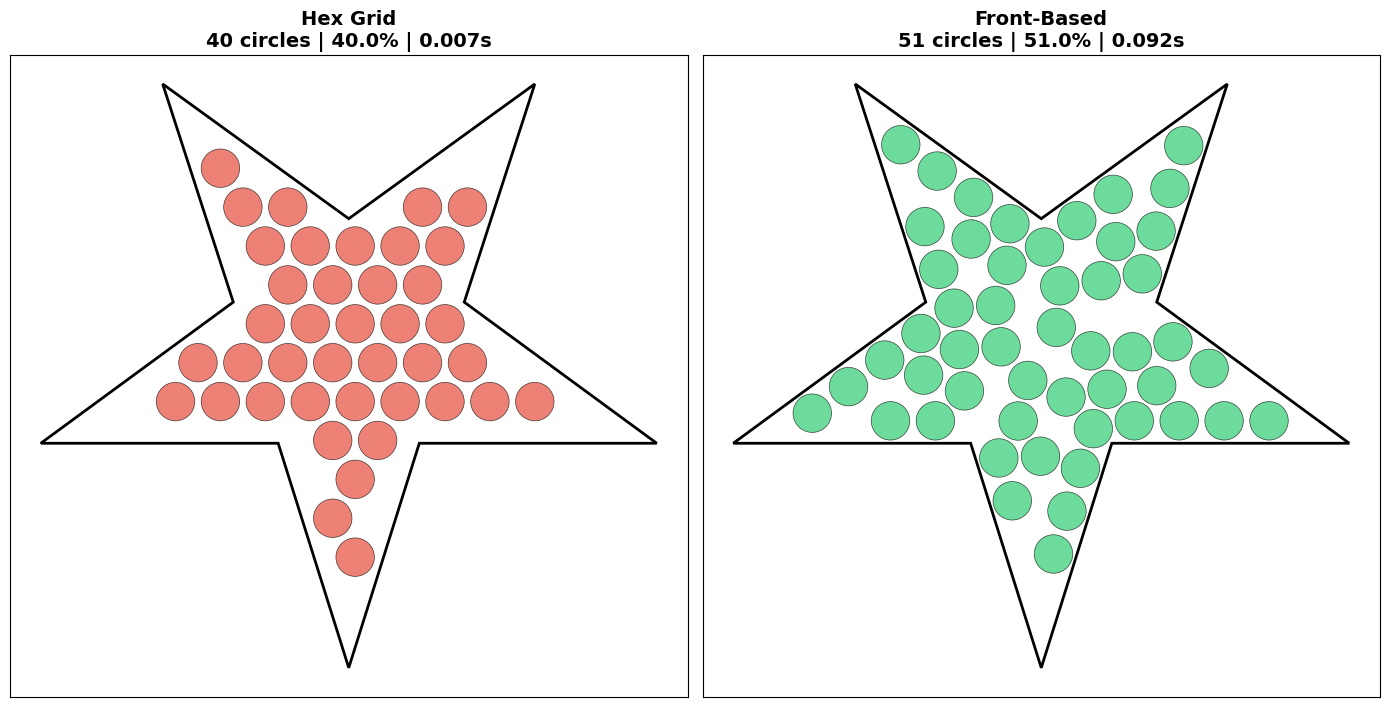

In [ ]:
print("=" * 75)
print("FRONT-BASED vs HEX GRID (Fixed Radius)")
print("=" * 75)

vertices = shapes["Star"]  # More interesting shape

results = []

# Hex grid
config_hex = PackingConfig(
    padding=0.5,
    fixed_radius=3.0,
    use_hex_grid=True,
    use_front_packing=False,
)
packer = CirclePacker([np.array(vertices)], config_hex)
start = time.perf_counter()
circles = packer.pack()
elapsed = time.perf_counter() - start
results.append(BenchmarkResult("Hex Grid", elapsed, circles, Polygon(vertices).area))

# Front-based
config_front = PackingConfig(
    padding=0.5,
    fixed_radius=3.0,
    use_front_packing=True,
    verbose=True,
)
packer = CirclePacker([np.array(vertices)], config_front)
start = time.perf_counter()
circles = packer.pack()
elapsed = time.perf_counter() - start
results.append(BenchmarkResult("Front-Based", elapsed, circles, Polygon(vertices).area))

print("\n" + "-" * 75)
for r in results:
    print(r.summary())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
colors = ["#e74c3c", "#2ecc71"]

for ax, result, color in zip(axes, results, colors):
    poly_patch = MplPolygon(vertices, fill=False, edgecolor="black", linewidth=2)
    ax.add_patch(poly_patch)

    for x, y, r in result.circles:
        circle = MplCircle((x, y), r, fill=True, facecolor=color,
                          edgecolor="black", alpha=0.7, linewidth=0.5)
        ax.add_patch(circle)

    ax.set_title(f"{result.name}\n{result.circle_count} circles | {result.density:.1f}% | {result.time_seconds:.3f}s",
                fontsize=14, fontweight="bold")
    ax.set_aspect("equal")
    ax.autoscale_view()
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

STATE-OF-THE-ART HYBRID PACKING TEST

SQUARE
HYBRID MODE (Variable Radius)
Estimated max radius: 42.8

Phase 1: Large circles (>= 50% of max = 21.4)
  Seeded 119 initial candidates
  Placed 1 large circles

Phase 2: Medium circles (>= 25% of max = 10.7)
  Seeded 0 initial candidates
  Placed 0 medium circles

Phase 3: Small circles (random sampling)
[Small] Placed: 26 | Failed: 0/150 (0%)
[Small] Placed: 51 | Failed: 0/150 (0%)
  Added 54 small circles

TOTAL: 55 circles, 85.8% density

---------------------------------------------------------------------------
Random                    | Time:  0.314s | Circles:   49 | Density:  86.4%
Front                     | Time:  0.372s | Circles:   70 | Density:  86.0%
Hybrid                    | Time:  0.151s | Circles:   55 | Density:  85.8%


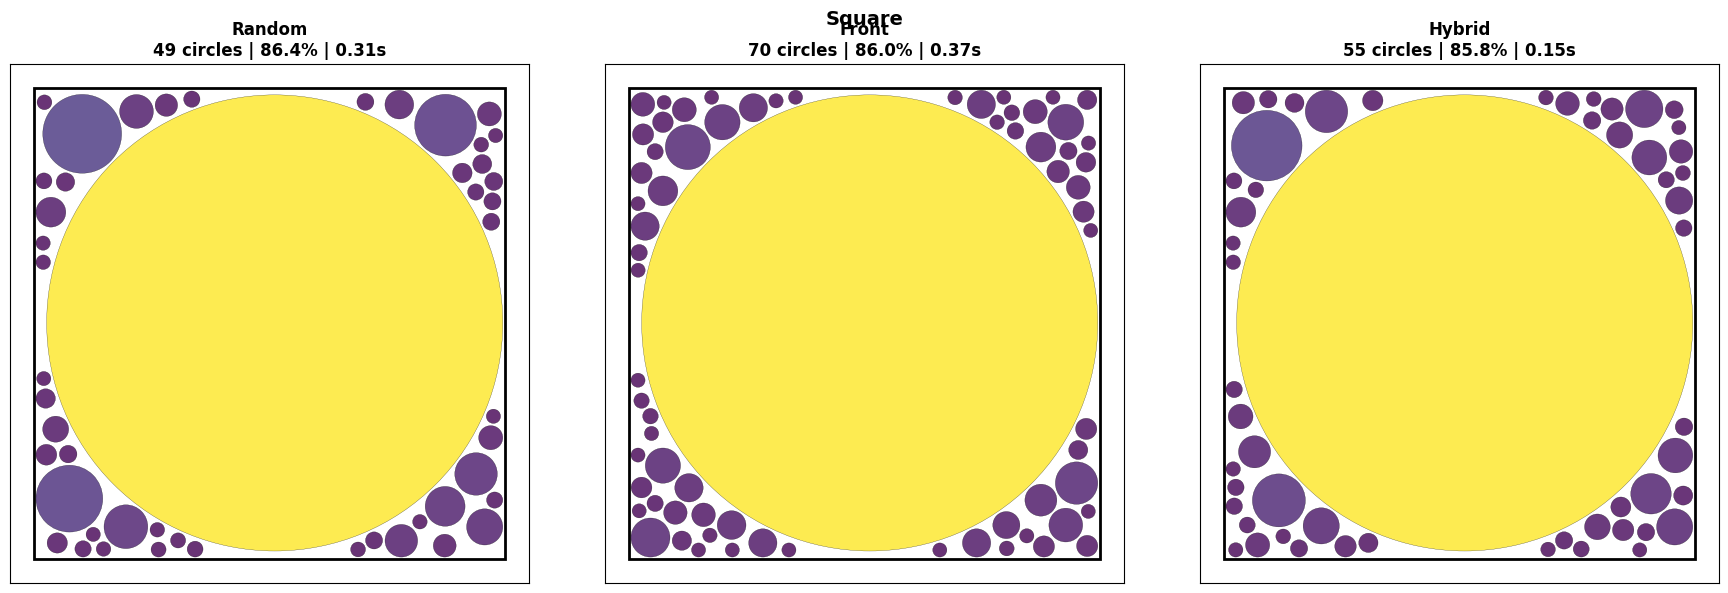


L-SHAPE
HYBRID MODE (Variable Radius)
Estimated max radius: 22.2

Phase 1: Large circles (>= 50% of max = 11.1)
  Seeded 156 initial candidates
  Placed 2 large circles

Phase 2: Medium circles (>= 25% of max = 5.6)
  Seeded 32 initial candidates
  Placed 5 medium circles

Phase 3: Small circles (random sampling)
[Small] Placed: 32 | Failed: 0/150 (0%)
  Added 29 small circles

TOTAL: 36 circles, 79.3% density

---------------------------------------------------------------------------
Random                    | Time:  0.678s | Circles:   50 | Density:  76.9%
Front                     | Time:  0.739s | Circles:   72 | Density:  73.9%
Hybrid                    | Time:  0.296s | Circles:   36 | Density:  79.3%


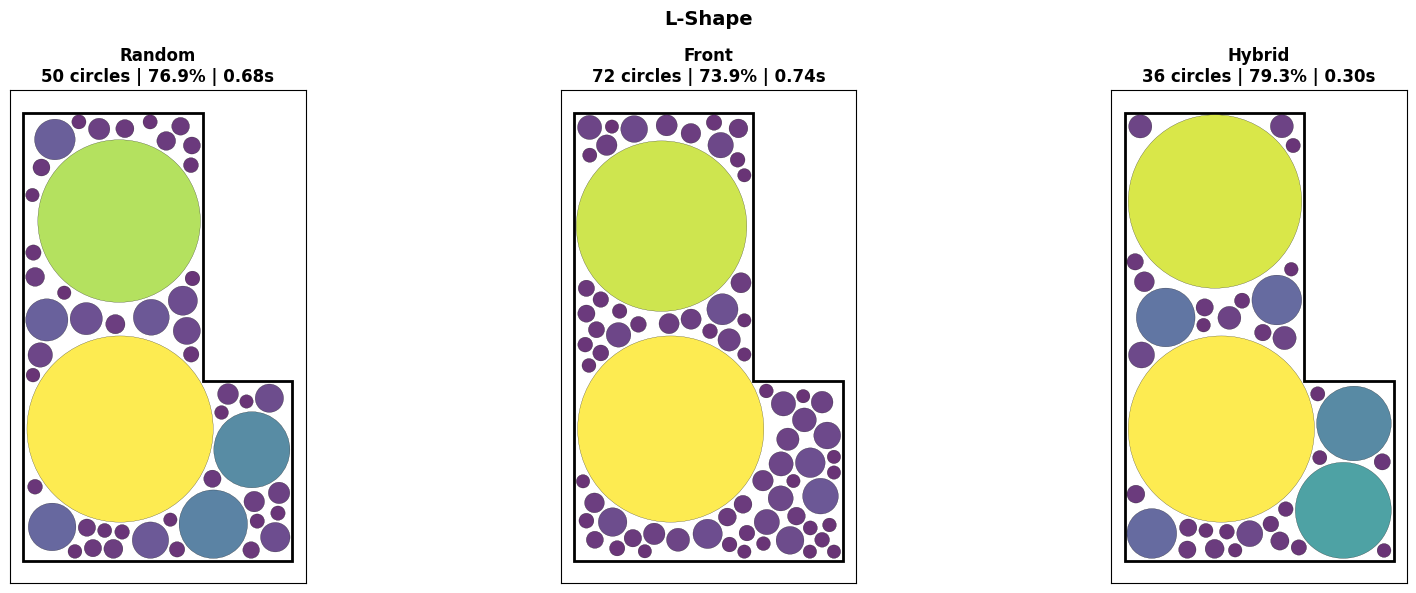


STAR
HYBRID MODE (Variable Radius)
Estimated max radius: 10.8

Phase 1: Large circles (>= 50% of max = 5.4)
  Seeded 157 initial candidates
  Placed 6 large circles

Phase 2: Medium circles (>= 25% of max = 2.7)
  Seeded 50 initial candidates
  Placed 5 medium circles

Phase 3: Small circles (random sampling)
  Added 16 small circles

TOTAL: 27 circles, 68.8% density

---------------------------------------------------------------------------
Random                    | Time:  0.317s | Circles:   39 | Density:  64.4%
Front                     | Time:  0.293s | Circles:   49 | Density:  66.0%
Hybrid                    | Time:  0.248s | Circles:   27 | Density:  68.8%


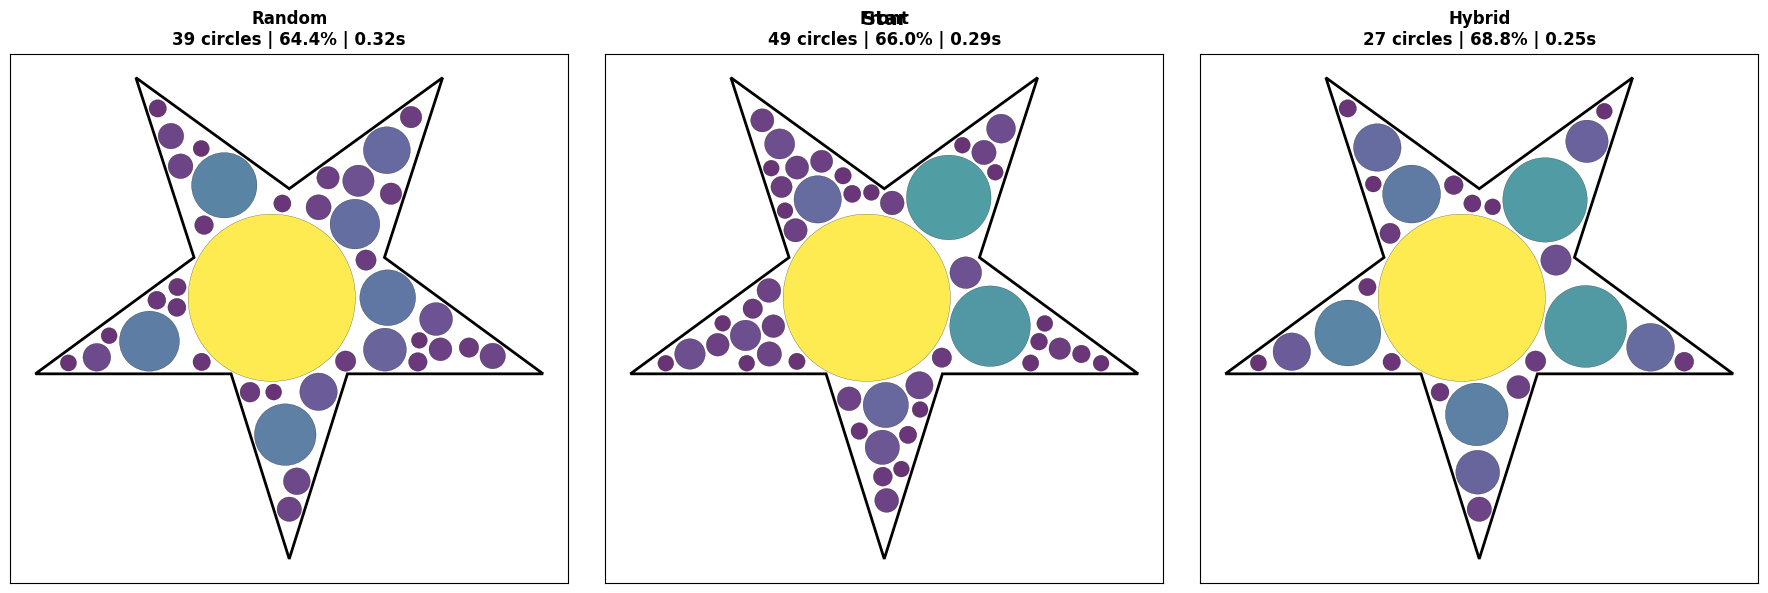

In [ ]:
print("=" * 75)
print("STATE-OF-THE-ART HYBRID PACKING TEST")
print("=" * 75)

# Test on all shapes
for shape_name, vertices in shapes.items():
    print(f"\n{'='*75}")
    print(f"{shape_name.upper()}")
    print("="*75)

    results = []

    # Random sampling (baseline)
    np.random.seed(42)
    config = PackingConfig(
        padding=0.5,
        min_radius=1.5,
        max_failed_attempts=300,
    )
    packer = CirclePacker([np.array(vertices)], config)
    start = time.perf_counter()
    circles = packer.pack()
    elapsed = time.perf_counter() - start
    results.append(BenchmarkResult("Random", elapsed, circles, Polygon(vertices).area))

    # Front-based
    np.random.seed(42)
    config = PackingConfig(
        padding=0.5,
        min_radius=1.5,
        use_front_packing=True,
    )
    packer = CirclePacker([np.array(vertices)], config)
    start = time.perf_counter()
    circles = packer.pack()
    elapsed = time.perf_counter() - start
    results.append(BenchmarkResult("Front", elapsed, circles, Polygon(vertices).area))

    # Hybrid (state-of-the-art)
    np.random.seed(42)
    config = PackingConfig(
        padding=0.5,
        min_radius=1.5,
        max_failed_attempts=150,
        use_hybrid_packing=True,
        verbose=True,
    )
    packer = CirclePacker([np.array(vertices)], config)
    start = time.perf_counter()
    circles = packer.pack()
    elapsed = time.perf_counter() - start
    results.append(BenchmarkResult("Hybrid", elapsed, circles, Polygon(vertices).area))

    print("\n" + "-" * 75)
    for r in results:
        print(r.summary())

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, result in zip(axes, results):
        poly_patch = MplPolygon(vertices, fill=False, edgecolor="black", linewidth=2)
        ax.add_patch(poly_patch)

        if result.circles:
            radii_list = [c[2] for c in result.circles]
            max_r, min_r = max(radii_list), min(radii_list)
            for x, y, r in result.circles:
                norm_r = (r - min_r) / (max_r - min_r + 1e-10)
                circle = MplCircle((x, y), r, fill=True, facecolor=plt.cm.viridis(norm_r),
                                  edgecolor="black", alpha=0.8, linewidth=0.2)
                ax.add_patch(circle)

        ax.set_title(f"{result.name}\n{result.circle_count} circles | {result.density:.1f}% | {result.time_seconds:.2f}s",
                    fontsize=12, fontweight="bold")
        ax.set_aspect("equal")
        ax.autoscale_view()
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle(shape_name, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

HYBRID vs HEX GRID (Fixed Radius)
HYBRID MODE (Fixed Radius)

Phase 1: Front-based placement (r=3.0)
  Seeded 35 initial candidates
  Placed 51 circles

Phase 2: Hex grid gap filling
Hex grid: 288 total -> 73 inside -> 0 valid
  Added 0 circles

TOTAL: 51 circles, 51.0% density

---------------------------------------------------------------------------
Hex Grid                  | Time:  0.007s | Circles:   40 | Density:  40.0%
Hybrid                    | Time:  0.083s | Circles:   51 | Density:  51.0%


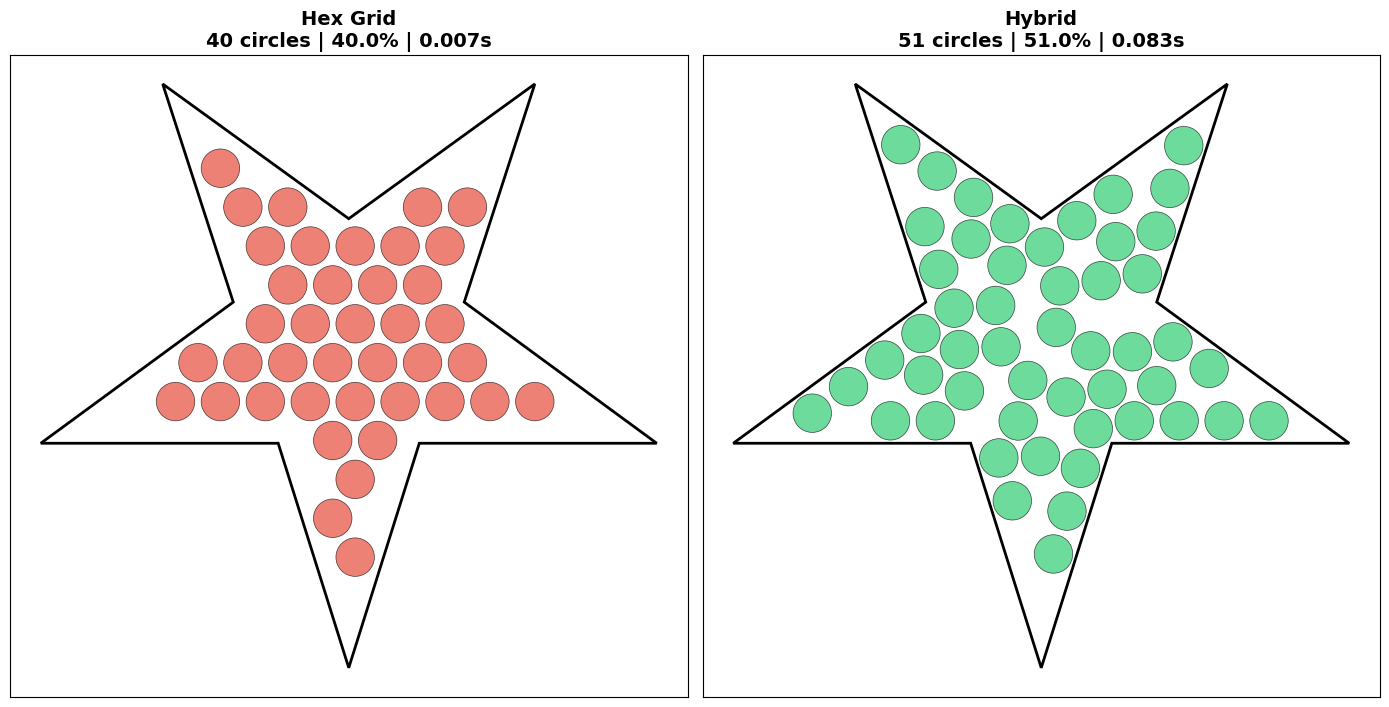

In [ ]:
print("=" * 75)
print("HYBRID vs HEX GRID (Fixed Radius)")
print("=" * 75)

vertices = shapes["Star"]

results = []

# Hex grid
config = PackingConfig(
    padding=0.5,
    fixed_radius=3.0,
    use_hex_grid=True,
)
packer = CirclePacker([np.array(vertices)], config)
start = time.perf_counter()
circles = packer.pack()
elapsed = time.perf_counter() - start
results.append(BenchmarkResult("Hex Grid", elapsed, circles, Polygon(vertices).area))

# Hybrid
config = PackingConfig(
    padding=0.5,
    fixed_radius=3.0,
    use_hybrid_packing=True,
    verbose=True,
)
packer = CirclePacker([np.array(vertices)], config)
start = time.perf_counter()
circles = packer.pack()
elapsed = time.perf_counter() - start
results.append(BenchmarkResult("Hybrid", elapsed, circles, Polygon(vertices).area))

print("\n" + "-" * 75)
for r in results:
    print(r.summary())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
colors = ["#e74c3c", "#2ecc71"]

for ax, result, color in zip(axes, results, colors):
    poly_patch = MplPolygon(vertices, fill=False, edgecolor="black", linewidth=2)
    ax.add_patch(poly_patch)

    for x, y, r in result.circles:
        circle = MplCircle((x, y), r, fill=True, facecolor=color,
                          edgecolor="black", alpha=0.7, linewidth=0.5)
        ax.add_patch(circle)

    ax.set_title(f"{result.name}\n{result.circle_count} circles | {result.density:.1f}% | {result.time_seconds:.3f}s",
                fontsize=14, fontweight="bold")
    ax.set_aspect("equal")
    ax.autoscale_view()
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()